<a href="https://colab.research.google.com/github/tusharj23/ProteinBERT/blob/main/notebooks/TAPE_Transformer_without_pretraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tape-proteins

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.1 MB/s eta 0:00:00


In [2]:
!wget https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz

--2026-03-18 17:43:54--  https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 54.231.136.168, 16.15.223.179, 16.15.207.184, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|54.231.136.168|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 251794897 (240M) [application/x-tar]
Saving to: ‘secondary_structure.tar.gz’

secondary_structure 100%[===================>] 240.13M  38.1MB/s    in 6.4s    

2026-03-18 17:44:01 (37.4 MB/s) - ‘secondary_structure.tar.gz’ saved [251794897/251794897]



In [3]:
!mkdir -p data
!tar -xzf secondary_structure.tar.gz -C data

Detected vocab size: 29

MODEL ARCHITECTURE

Layer                     Activation Volume         Parameters     
Input                     16 x 512                  0              
Embedding                 16 x 512 x 256            7424           
LayerNorm                 16 x 512 x 256            512            
Positional Encoding       16 x 512 x 256            0              
Transformer Encoder       16 x 512 x 256            2108416        
Linear (FC)               16 x 512 x 3              771            


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/20 | Train Loss: 0.9998 | Train Acc: 0.5027 | Val Loss: 0.9523 | Val Acc: 0.5360
Epoch 2/20 | Train Loss: 0.9587 | Train Acc: 0.5300 | Val Loss: 0.9449 | Val Acc: 0.5377
Epoch 3/20 | Train Loss: 0.9305 | Train Acc: 0.5505 | Val Loss: 0.8825 | Val Acc: 0.5904
Epoch 4/20 | Train Loss: 0.8676 | Train Acc: 0.6000 | Val Loss: 0.8344 | Val Acc: 0.6208
Epoch 5/20 | Train Loss: 0.8402 | Train Acc: 0.6176 | Val Loss: 0.8308 | Val Acc: 0.6236
Epoch 6/20 | Train Loss: 0.8254 | Train Acc: 0.6266 | Val Loss: 0.8010 | Val Acc: 0.6415
Epoch 7/20 | Train Loss: 0.8110 | Train Acc: 0.6344 | Val Loss: 0.7967 | Val Acc: 0.6434
Epoch 8/20 | Train Loss: 0.8015 | Train Acc: 0.6397 | Val Loss: 0.7837 | Val Acc: 0.6501
Epoch 9/20 | Train Loss: 0.7916 | Train Acc: 0.6461 | Val Loss: 0.7680 | Val Acc: 0.6589
Epoch 10/20 | Train Loss: 0.7804 | Train Acc: 0.6518 | Val Loss: 0.7715 | Val Acc: 0.6584
Epoch 11/20 | Train Loss: 0.7730 | Train Acc: 0.6564 | Val Loss: 0.7563 | Val Acc: 0.6649
Epoch 12/20 | Train

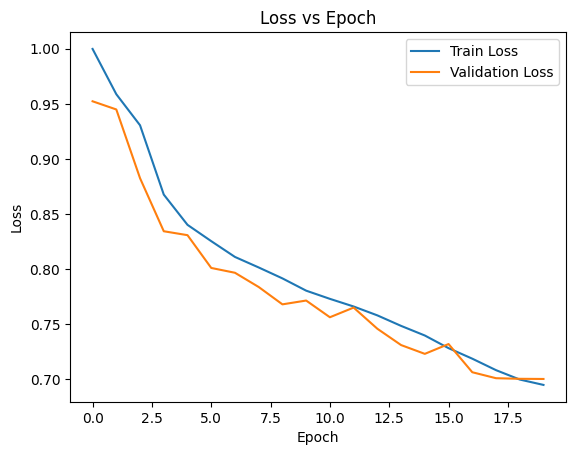

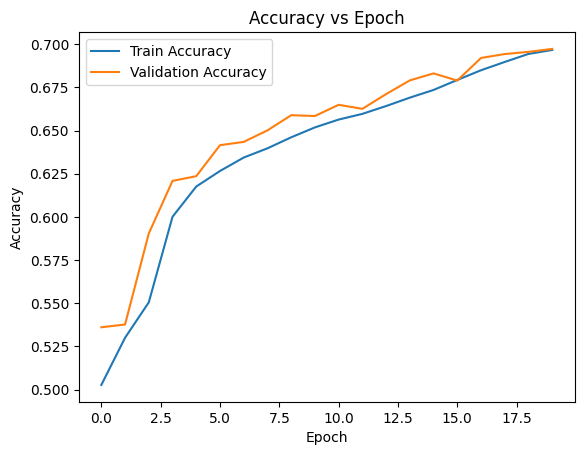

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import math
import matplotlib.pyplot as plt
from tape.datasets import SecondaryStructureDataset

# Hyperparameters
LR = 1e-3
MAX_LEN = 512
BATCH_SIZE = 16
EPOCHS = 20
d_model = 256
heads = 8
layers = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Dataset Wrapper
class TapeDataset(Dataset):

    def __init__(self, split):
        self.dataset = SecondaryStructureDataset(
            data_path="./data",
            split=split
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        token_ids, input_mask, labels = self.dataset[idx]

        seq = torch.tensor(token_ids)
        label = torch.tensor(labels)

        seq = seq[:MAX_LEN]
        label = label[:MAX_LEN]

        if len(seq) < MAX_LEN:

            pad_len = MAX_LEN - len(seq)

            seq = torch.cat([seq, torch.zeros(pad_len).long()])

            label = torch.cat([
                label,
                torch.full((pad_len,), -1).long()
            ])

        return seq, label


# Load Dataset
train_dataset = TapeDataset("train")
valid_dataset = TapeDataset("valid")
test_dataset = TapeDataset("cb513")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


# Detect Vocabulary Size
max_token = 0

for i in range(500):

    token_ids, _, _ = train_dataset.dataset[i]

    max_token = max(max_token, max(token_ids))

VOCAB_SIZE = max_token + 1

print("Detected vocab size:", VOCAB_SIZE)


# Positional Encoding
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=1000):

        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]


# Transformer Model
class ProteinTransformer(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)

        self.norm = nn.LayerNorm(d_model)

        self.pos_encoding = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=heads,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers
        )

        self.fc = nn.Linear(d_model, 3)

    def forward(self, x):

        mask = (x == 0)

        x = self.embedding(x)

        x = self.norm(x)

        x = self.pos_encoding(x)

        x = self.transformer(x, src_key_padding_mask=mask)

        x = self.fc(x)

        return x


# Model Initialization
model = ProteinTransformer(VOCAB_SIZE).to(device)


# Architecture Table
def print_model_table(model):

    x = torch.zeros(BATCH_SIZE, MAX_LEN).long().to(device)

    print("\nMODEL ARCHITECTURE\n")
    print("{:<25} {:<25} {:<15}".format("Layer","Activation Volume","Parameters"))

    print("{:<25} {:<25} {:<15}".format(
        "Input",
        f"{BATCH_SIZE} x {MAX_LEN}",
        "0"
    ))

    x = model.embedding(x)

    params = model.embedding.weight.numel()

    print("{:<25} {:<25} {:<15}".format(
        "Embedding",
        f"{x.shape[0]} x {x.shape[1]} x {x.shape[2]}",
        params
    ))

    x = model.norm(x)

    params = sum(p.numel() for p in model.norm.parameters())

    print("{:<25} {:<25} {:<15}".format(
        "LayerNorm",
        f"{x.shape[0]} x {x.shape[1]} x {x.shape[2]}",
        params
    ))

    x = model.pos_encoding(x)

    print("{:<25} {:<25} {:<15}".format(
        "Positional Encoding",
        f"{x.shape[0]} x {x.shape[1]} x {x.shape[2]}",
        "0"
    ))

    mask = torch.zeros(BATCH_SIZE, MAX_LEN).bool().to(device)

    x = model.transformer(x, src_key_padding_mask=mask)

    params = sum(p.numel() for p in model.transformer.parameters())

    print("{:<25} {:<25} {:<15}".format(
        "Transformer Encoder",
        f"{x.shape[0]} x {x.shape[1]} x {x.shape[2]}",
        params
    ))

    x = model.fc(x)

    params = sum(p.numel() for p in model.fc.parameters())

    print("{:<25} {:<25} {:<15}".format(
        "Linear (FC)",
        f"{x.shape[0]} x {x.shape[1]} x {x.shape[2]}",
        params
    ))


print_model_table(model)


# Training Setup
criterion = nn.CrossEntropyLoss(ignore_index=-1)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses = []
train_accs = []
val_accs = []


# Training Loop
for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for seq, label in train_loader:

        seq = seq.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        output = model(seq)

        pred = torch.argmax(output, dim=-1)

        mask = label != -1

        correct += ((pred == label) * mask).sum().item()
        total += mask.sum().item()

        output = output.view(-1, 3)
        label = label.view(-1)

        loss = criterion(output, label)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)


    # Validation
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for seq, label in valid_loader:

            seq = seq.to(device)
            label = label.to(device)

            output = model(seq)

            pred = torch.argmax(output, dim=-1)

            mask = label != -1

            correct += ((pred == label) * mask).sum().item()
            total += mask.sum().item()

            output = output.view(-1, 3)
            label = label.view(-1)

            loss = criterion(output, label)

            total_loss += loss.item()

    val_loss = total_loss / len(valid_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )


# Test Evaluation
model.eval()

total_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for seq, label in test_loader:

        seq = seq.to(device)
        label = label.to(device)

        output = model(seq)

        pred = torch.argmax(output, dim=-1)

        mask = label != -1

        correct += ((pred == label) * mask).sum().item()
        total += mask.sum().item()

        output = output.view(-1, 3)
        label = label.view(-1)

        loss = criterion(output, label)

        total_loss += loss.item()

test_loss = total_loss / len(test_loader)
test_acc = correct / total

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_acc)


# Plot Loss
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()


# Plot Accuracy
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

In [26]:
def run_custom_sequence(model):

    model.eval()


    print("CUSTOM SEQUENCE FLOW")


    # Given Sequence
    seq_str = "AAYPIEFTYPDGQNGEQGFQGAHFLAFG"
    label_str = "CCEEEEEEECCHHHHHHHHHHHHCCCC"


    # Mapping
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    aa_to_id = {aa: i+1 for i, aa in enumerate(amino_acids)}

    label_map = {"H": 0, "E": 1, "C": 2}
    inv_map = {0: "H", 1: "E", 2: "C"}

    # Convert to IDs
    seq_ids = [aa_to_id.get(a, 0) for a in seq_str]
    label_ids = [label_map[s] for s in label_str]

    print("Original Length:", len(seq_ids))

    seq = torch.tensor(seq_ids)
    label = torch.tensor(label_ids)


    # Padding
    if len(seq) < MAX_LEN:

        pad = MAX_LEN - len(seq)

        seq = torch.cat([seq, torch.zeros(pad).long()])
        label = torch.cat([
            label,
            torch.full((pad,), -1).long()
        ])

        print("After Padding Length:", len(seq))

    seq = seq.unsqueeze(0).to(device)
    label = label.unsqueeze(0).to(device)


    # Forward Pass
    print("\n--- Forward Pass ---")

    x = model.embedding(seq)
    print("Embedding Output:", x.shape)

    if hasattr(model, "norm"):
        x = model.norm(x)
        print("After LayerNorm:", x.shape)

    x = model.pos_encoding(x)
    print("After Positional Encoding:", x.shape)

    mask = (seq == 0)

    if hasattr(model, "transformer"):
        x = model.transformer(x, src_key_padding_mask=mask)
    else:
        x = model.encoder(x, src_key_padding_mask=mask)

    print("After Transformer:", x.shape)

    if hasattr(model, "classifier"):
        out = model.classifier(x)
    else:
        out = model.fc(x)

    print("Final Output:", out.shape)


    # Predictions
    pred = torch.argmax(out, dim=-1).squeeze().cpu().numpy()
    label = label.squeeze().cpu().numpy()

    # Remove padding safely
    clean_pred = []
    clean_label = []

    for p, l in zip(pred, label):
        if l != -1:
            clean_pred.append(int(p))
            clean_label.append(int(l))

    pred_str = "".join([inv_map[p] for p in clean_pred])
    true_str = "".join([inv_map[l] for l in clean_label])

    print("\n--- Results ---")
    print("Sequence: ", seq_str)
    print("True SS : ", true_str)
    print("Pred SS : ", pred_str)


run_custom_sequence(model)

CUSTOM SEQUENCE FLOW
Original Length: 28
After Padding Length: 512

--- Forward Pass ---
Embedding Output: torch.Size([1, 512, 256])
After LayerNorm: torch.Size([1, 512, 256])
After Positional Encoding: torch.Size([1, 512, 256])
After Transformer: torch.Size([1, 512, 256])
Final Output: torch.Size([1, 512, 3])

--- Results ---
Sequence:  AAYPIEFTYPDGQNGEQGFQGAHFLAFG
True SS :  CCEEEEEEECCHHHHHHHHHHHHCCCC
Pred SS :  CCCCHHHHCCHHHHHHHHHHHHHHHHH
